In [1]:
# import useful libraries
import numpy as np
import matplotlib.pyplot as plt
import torch 

import sys
from pathlib import Path

# set parent directory to sys.path for imports
NOTEBOOK_DIR = Path.cwd().resolve()
PARENT_DIR = NOTEBOOK_DIR.parents[2]
if str(PARENT_DIR) not in sys.path:
    sys.path.insert(0, str(PARENT_DIR))
    print(f"Parent directory added to sys.path: ...\\{PARENT_DIR.name}")
else:
    print(f"Parent directory already in sys.path: ...\\{PARENT_DIR.name}")


# set dataset directory path
DATA_TEST_PATH = PARENT_DIR / "data" / "test"
print("Dataset directory used:", f"...\\{PARENT_DIR.name}\\{DATA_TEST_PATH.relative_to(PARENT_DIR)}")

Parent directory added to sys.path: ...\STL-Dev
Dataset directory used: ...\STL-Dev\data\test


Shape Original Data = torch.Size([256, 256])


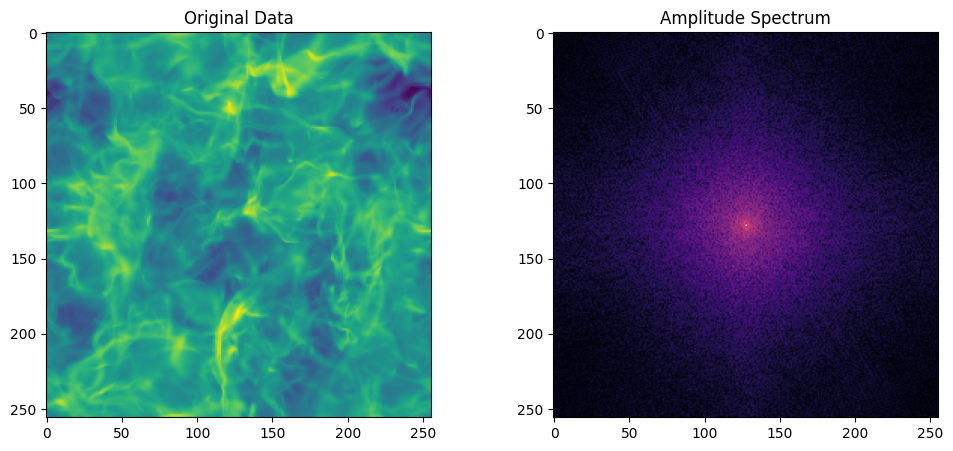

In [103]:
# Load some perioc data
data = np.load(str(DATA_TEST_PATH) + "/" + "Turb_6.npy")[0]
data = torch.from_numpy(data)
data_fft = torch.abs(torch.fft.fftshift(torch.fft.fft2(data)))


# Display data and its amplitude spectrum
print("Shape Original Data = " + str(data.shape))
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.title("Original Data")
plt.imshow(data)

plt.subplot(1, 2, 2)
plt.title("Amplitude Spectrum")
plt.imshow(torch.log1p(data_fft), cmap="magma")

Shape No PBC Data = torch.Size([128, 128])


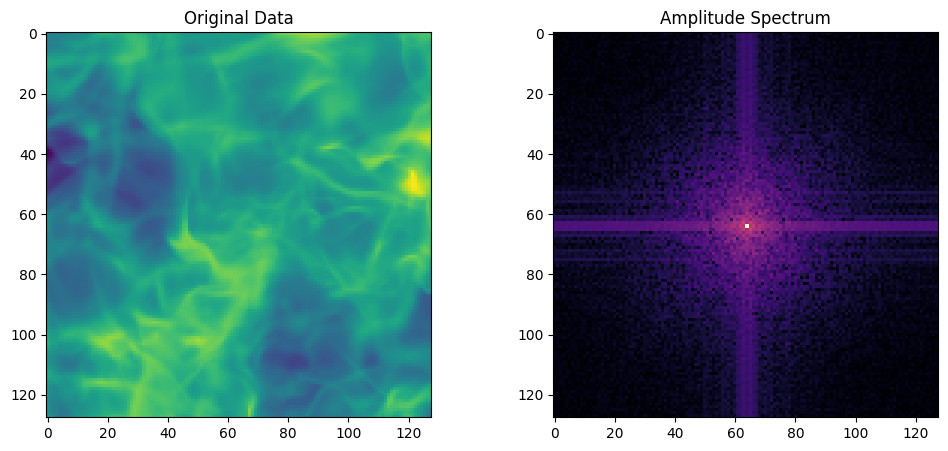

In [104]:
# Load some perioc data
data_no_pbc = data[0:128, 0:128]
data_no_pbc_fft = torch.abs(torch.fft.fftshift(torch.fft.fft2(data_no_pbc)))


# Display data and its amplitude spectrum
print("Shape No PBC Data = " + str(data_no_pbc.shape))
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.title("Original Data")
plt.imshow(data_no_pbc)

plt.subplot(1, 2, 2)
plt.title("Amplitude Spectrum")
plt.imshow(torch.log1p(data_no_pbc_fft), cmap="magma")

### Windowing

In [107]:
def _build_bin_masks(data, n_bins, min_freq):

    # --- create frequency grid ---
    N, M = data.shape
    freq_y = torch.fft.fftshift(torch.fft.fftfreq(N)) * N  # [-N/2, ..., N/2]
    freq_x = torch.fft.fftshift(torch.fft.fftfreq(M)) * M  # [-M/2, ..., M/2]
    FY, FX = torch.meshgrid(freq_y, freq_x, indexing="ij")  # 2D grid

    # --- radial frequency grid ---
    R = torch.sqrt(FX**2 + FY**2)  # distance from zero frequency

    max_freq = min(N, M) // 2  # Nyquist
    bin_edges = torch.linspace(min_freq, max_freq, n_bins + 1)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])  # [n_bins] (for plotting)

    # --- create masks for each bin ---
    bin_edges_exp = bin_edges.unsqueeze(1).unsqueeze(2)  # [n_bins+1,1,1]
    R_exp = R.unsqueeze(0)  # [1, N, M]

    bin_masks = ((R_exp >= bin_edges_exp[:-1]) & (R_exp < bin_edges_exp[1:])) # [n_bins, N, M]

    return bin_masks, bin_centers

In [108]:
# Windowing method
def apply_window(data, window_type):
    N, M = data.shape
    if window_type == "rect":
        wx = torch.ones(M)
        wy = torch.ones(N)
    if window_type == "hann":
        wy = torch.hann_window(N, periodic=False)
        wx = torch.hann_window(M, periodic=False)
    elif window_type == "hamming":
        wy = torch.hamming_window(N, periodic=False)
        wx = torch.hamming_window(M, periodic=False)
    elif window_type == "kaiser":
        beta = 1
        wy = torch.kaiser_window(N, beta=beta, periodic=False)
        wx = torch.kaiser_window(M, beta=beta, periodic=False)
    window_2d = wy[:, None] * wx[None, :]
    G = (N*M) / torch.sum(window_2d**2).item() 
    return data * window_2d, G

def compute_power_spectrum(data, n_bins, G, min_freq=1):
    # Compute 2D FFT
    data_fft = torch.fft.fftshift(torch.fft.fft2(data, norm="ortho"))
    ps_2d = G * torch.abs(data_fft/(data.shape[0]*data.shape[1])) ** 2

    bin_masks, _ = _build_bin_masks(data, n_bins, min_freq)

    # Average power in each frequency bin
    ps_values = []
    for b in range(bin_masks.shape[0]):
        mask = bin_masks[b]  
        masked_ps = ps_2d * mask
        bin_sum = masked_ps.sum()
        bin_count = mask.sum()
        ps_avg = bin_sum / bin_count if bin_count > 0 else 0
        ps_values.append(ps_avg.item())
    return torch.tensor(ps_values)

# Compute power spectrum with different windowing methods
data_windowed_rect, G_rect = apply_window(data, window_type="rect")
ps_data_windowed_rect = compute_power_spectrum(data_windowed_rect, n_bins=16, G=G_rect, min_freq=1)[:8]

data_no_pbc_windowed_rect, G_no_pbc_rect = apply_window(data_no_pbc, window_type="rect")
ps_data_no_pbc_windowed_rect = compute_power_spectrum(data_no_pbc_windowed_rect, G=G_no_pbc_rect, n_bins=8, min_freq=1)

data_no_pbc_windowed_hann, G_no_pbc_hann = apply_window(data_no_pbc, window_type="hann")
ps_data_no_pbc_windowed_hann = compute_power_spectrum(data_no_pbc_windowed_hann, G=G_no_pbc_hann, n_bins=8, min_freq=1)

data_no_pbc_windowed_hamming, G_no_pbc_hamming = apply_window(data_no_pbc, window_type="hamming")
ps_data_no_pbc_windowed_hamming = compute_power_spectrum(data_no_pbc_windowed_hamming, G=G_no_pbc_hamming, n_bins=8, min_freq=1)

data_no_pbc_windowed_kaiser, G_no_pbc_kaiser = apply_window(data_no_pbc, window_type="kaiser")
ps_data_no_pbc_windowed_kaiser = compute_power_spectrum(data_no_pbc_windowed_kaiser, G=G_no_pbc_kaiser, n_bins=8, min_freq=1)

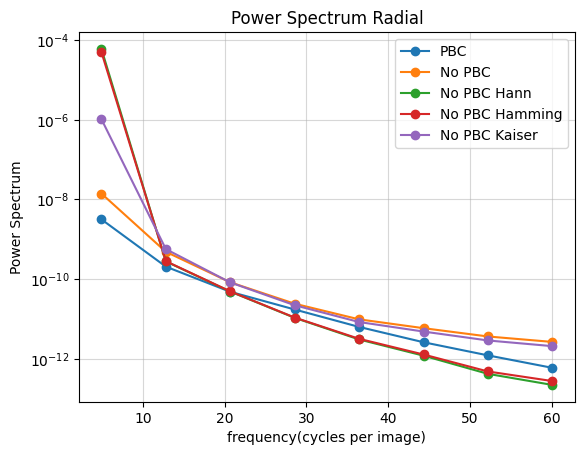

In [109]:
# Compare PS plot for PBC and non-PBC data
_, bin_centers = _build_bin_masks(data_no_pbc, n_bins=8, min_freq=1)
plt.plot(bin_centers, ps_data_windowed_rect, "-", marker="o", label="PBC")
plt.plot(bin_centers, ps_data_no_pbc_windowed_rect, "-", marker="o", label="No PBC")
plt.plot(bin_centers, ps_data_no_pbc_windowed_hann, "-", marker="o", label="No PBC Hann")
plt.plot(bin_centers, ps_data_no_pbc_windowed_hamming, "-", marker="o", label="No PBC Hamming")
plt.plot(bin_centers, ps_data_no_pbc_windowed_kaiser, "-", marker="o", label="No PBC Kaiser")

plt.yscale("log")
plt.xlabel("frequency(cycles per image)")
plt.ylabel("Power Spectrum")
plt.title("Power Spectrum Radial")
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()

### Cropping

In [2]:
from STL_main.STL_2D_FFT_Torch import STL_2D_FFT_Torch
from STL_main.STL_2D_FFT_Torch import WavelateOperator2D_FFT_torch

In [3]:
# command to auto-reload modules when they are edited (easier for testing and debugging)
%load_ext autoreload
%autoreload 2

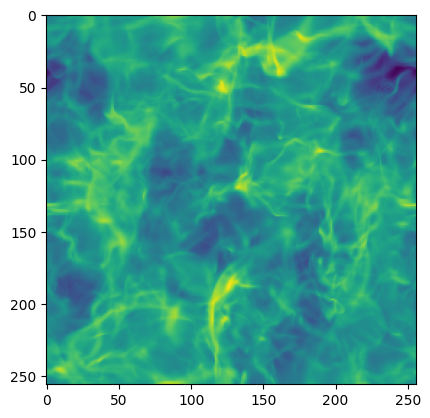

In [4]:
# Load some perioc data
data_array = np.load(str(DATA_TEST_PATH) + "/" + "Turb_6.npy")[0]
data = STL_2D_FFT_Torch(array=data_array, pbc=True)
data_no_pbc = STL_2D_FFT_Torch(array=data_array, pbc=False)
plt.imshow(data.array)

In [ ]:
ps_op = data.get_PS_op()

12


In [37]:
print(ps_op.min_freq)
print(ps_op.max_freq)
print(ps_op.bin_masks.shape)
print(ps_op.crop_borders)

4
128
torch.Size([16, 256, 256])
tensor([21, 19, 18, 17, 17, 15, 15, 15, 15, 12, 14, 14, 13, 12, 11,  4])


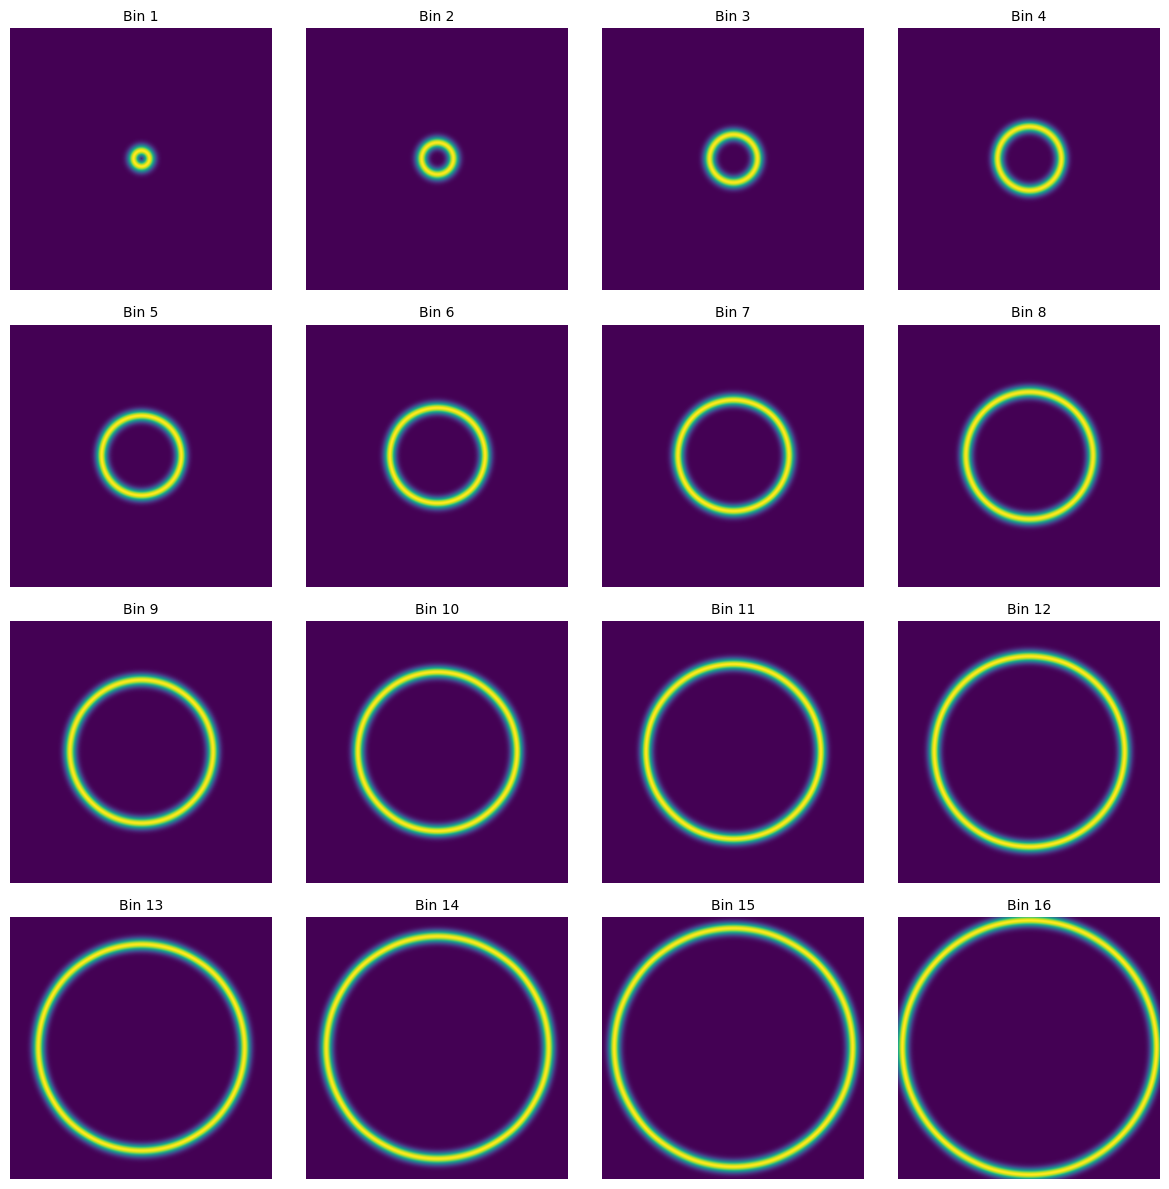

In [38]:
plt.figure(figsize=(12, 12)) 

n_rows, n_cols = 4, 4       

for i in range(ps_op.bin_masks.shape[0]):
    plt.subplot(n_rows, n_cols, i + 1)
    plt.imshow(ps_op.bin_masks[i].cpu(), cmap='viridis', origin='lower')
    plt.title(f"Bin {i+1}", fontsize=10)
    plt.axis('off')  

plt.tight_layout()
plt.show()

In [39]:
power_spectrum = ps_op.apply(data)
power_spectrum_no_pbc = ps_op.apply(data_no_pbc, get_crop_border_size_method="flexible_crop")

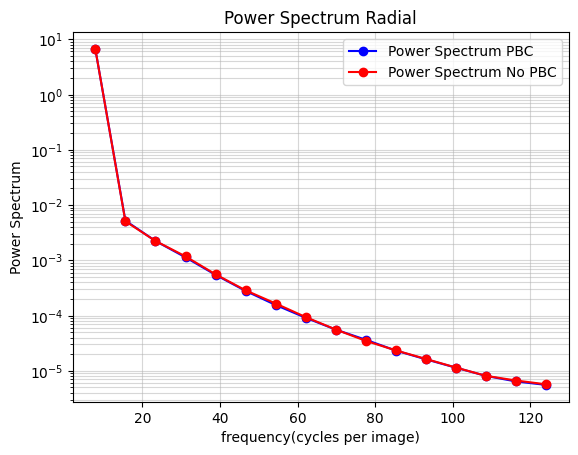

In [40]:
ps_op.plot_PS(power_spectrum, b=0, c=0, label="Power Spectrum PBC", color="b")
ps_op.plot_PS(power_spectrum_no_pbc, b=0, c=0, label="Power Spectrum No PBC", color="r")

Great, it fits pretty well !

Let's now compare power spectrum between pbc and real non pbc data

In [46]:
# Load some perioc data
data_array = np.load(str(DATA_TEST_PATH) + "/" + "Turb_6.npy")[0]
data = STL_2D_FFT_Torch(array=data_array, pbc=True)

# extract non-PBC portion
data_no_pbc = data_array[0:128, 0:128]
data_no_pbc = STL_2D_FFT_Torch(array=data_no_pbc, pbc=False)

In [56]:
ps_op = data.get_PS_op(n_bins=16)
ps_op_no_pbc = data_no_pbc.get_PS_op(n_bins=8, bin_edges=ps_op.bin_edges[:9])

In [57]:
power_spectrum = ps_op.apply(data)
power_spectrum_no_pbc = ps_op_no_pbc.apply(data_no_pbc, get_crop_border_size_method="flexible_crop")

In [ ]:
print(ps_op)

C:\Users\Danie\AppData\Roaming\Python\Python311\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\Danie\AppData\Roaming\Python\Python311\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


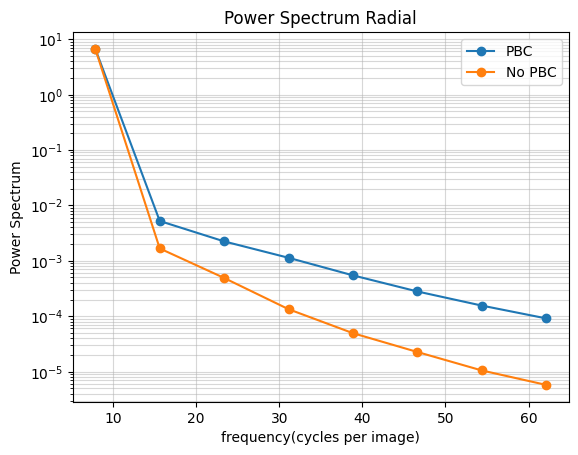

In [59]:
plt.plot(ps_op.bin_centers[:8], power_spectrum[0, 0,:8], "-", marker="o", label="PBC")
plt.plot(ps_op_no_pbc.bin_centers, power_spectrum_no_pbc[0, 0], "-", marker="o", label="No PBC")

plt.yscale("log")
plt.xlabel("frequency(cycles per image)")
plt.ylabel("Power Spectrum")
plt.title("Power Spectrum Radial")
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()

C:\Users\Danie\AppData\Roaming\Python\Python311\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\Danie\AppData\Roaming\Python\Python311\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


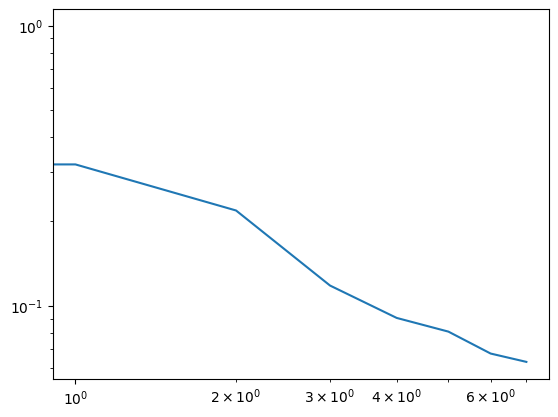

In [62]:
plt.plot(power_spectrum_no_pbc[0, 0]/power_spectrum[0, 0,:8])
plt.xscale("log")
plt.yscale("log")